# Streamflow signature metrics — definitions

The aggregate-signature calibration scores each simulation on **five** metrics computed
from the daily hydrograph (not on daily KGE/NSE, which go to the SI). This notebook
defines each one and draws a single figure showing where they live on the observed
East River regime.

Everything is on a **calendar-year** basis for readability. Two of the five are
*directional (circular) statistics* — the whole year is wrapped onto a circle so that
Dec 31 and Jan 1 sit next to each other, with no artificial seam.

## The five metrics

For each year $y$, let $Q_t$ be the daily flow on day-of-year $d_t$, with $D_y$ days in the
year and circular angle $\theta_t = 2\pi (d_t-1)/D_y$. Each metric is a **cost** (0 = perfect),
clipped to $[0,3]$; the objective is their equal-weighted mean.

**① COM timing** — flow-weighted circular mean date, mean absolute year-to-year error,
normalized to a 7-day tolerance:

$$\bar C_y=\frac{\sum_t \cos\theta_t\,Q_t}{\sum_t Q_t},\quad
  \bar S_y=\frac{\sum_t \sin\theta_t\,Q_t}{\sum_t Q_t},\qquad
  t_{\bar Q,y}=\frac{D_y}{2\pi}\,\operatorname{atan2}(\bar S_y,\bar C_y)$$

$$E_{\text{tim}}=\tfrac{1}{7}\,\big\langle\,\big|t_{\bar Q,y}^{\,\text{sim}}-t_{\bar Q,y}^{\,\text{obs}}\big|\,\big\rangle_y$$

**② Monthly volume** — volume-significant monthly bias. With $V_m$ the mean monthly runoff
(mm) and bias $b_m=V_m^{\text{sim}}-V_m^{\text{obs}}$, a month qualifies ($m\in\mathcal Q$) iff
$|b_m|/V_m^{\text{obs}}>0.10$ **and** $|b_m|>4$ mm:

$$E_{\text{vol}}=\frac{1}{0.10}\cdot\frac{\sum_{m\in\mathcal Q}|b_m|}{\sum_m V_m^{\text{obs}}}$$

**③ Concentration** — circular resultant length (peakiness: $0$ = uniform, $1$ = a single
instant), relative error:

$$R_y=\sqrt{\bar C_y^{\,2}+\bar S_y^{\,2}},\qquad
  E_{\text{con}}=\frac{\big\langle|R_y^{\text{sim}}-R_y^{\text{obs}}|\big\rangle_y}{\big\langle R_y^{\text{obs}}\big\rangle_y}$$

**④ Recession** — on each falling limb ($\ge 5$ consecutive declining days, baseflow season)
fit $\ln Q_t=\ln Q_0-t/\tau$; take the median $\tau$ over limbs; compare to a target $\tau^\star$:

$$E_{\text{rec}}=\frac{|\tau_{\text{sim}}-\tau^\star|}{\tau^\star}$$

**⑤ Sep–Nov low flow** — per-year 7-day minimum over Sep–Nov, mean absolute error in
$\log_{10}$ space (one decade $=1$), floored at $Q_{\text{floor}}=0.01\ \mathrm{m^3\,s^{-1}}$:

$$q_y=\min_{\text{Sep–Nov}}\overline{Q}_{7\mathrm d},\qquad
  E_{\text{low}}=\big\langle\big|\log_{10}q_y^{\text{sim}}-\log_{10}q_y^{\text{obs}}\big|\big\rangle_y$$

**Objective:** $\displaystyle \Phi=\tfrac15\big(E_{\text{tim}}+E_{\text{vol}}+E_{\text{con}}+E_{\text{rec}}+E_{\text{low}}\big)$

In [1]:
import calendar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- observed East River daily discharge (USGS 09112500) ---------------------
OBS  = ("/scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevAspect/"
        "observations/streamflow/preprocessed/East_River_USGS09112500_dailyQ_WY1970_2025.csv")
AREA = 748.25e6          # basin area (m^2); only scales the monthly-volume axis (mm)
Q_FLOOR = 0.01           # gauge measurement floor (m^3/s)
START, END = "1981-01-01", "2025-12-31"

obs = pd.read_csv(OBS, parse_dates=["datetime"]).set_index("datetime")["discharge_cms"]
q = obs[START:END].clip(lower=Q_FLOOR).dropna()

# --- ① timing + ③ concentration: circular statistics, per calendar year ------
def directional_stats(series):
    """Flow-weighted circular mean day (tQ) and resultant length (R) per year."""
    s = series[series > 0].dropna()
    rows = {}
    for y, g in s.groupby(s.index.year):
        D = 366.0 if calendar.isleap(y) else 365.0
        th = 2 * np.pi * (g.index.dayofyear.values - 1) / D
        Q, tot = g.values, g.values.sum()
        C, S = (np.cos(th) * Q).sum() / tot, (np.sin(th) * Q).sum() / tot
        tQ = (np.arctan2(S, C) % (2 * np.pi)) / (2 * np.pi) * D
        rows[int(y)] = (tQ, np.hypot(C, S))
    return pd.DataFrame(rows, index=["tQ_day", "R"]).T

# --- ④ recession: median tau over baseflow-season falling limbs --------------
def recession_tau(series, months=(10, 11, 12, 1, 2), min_len=5):
    s = series[series.index.month.isin(months)].dropna()
    s = s[s > 0]
    # split into runs of calendar-consecutive days so a limb never bridges a gap
    # in the record or the excluded melt season (a Feb -> Oct jump must not read
    # as one long fall). np.diff over the filtered array would otherwise do that.
    block = (s.index.to_series().diff().dt.days.fillna(1) != 1).cumsum()
    taus = []
    for _, blk in s.groupby(block):
        v = blk.values
        falling = np.r_[False, np.diff(v) < 0]
        i, n = 0, len(v)
        while i < n:
            if falling[i]:
                j = i
                while j < n and falling[j]:
                    j += 1
                seg = v[i - 1:j]                          # include the pre-peak point
                if len(seg) >= min_len and np.all(np.diff(seg) < 0):   # strictly falling
                    slope = np.polyfit(np.arange(len(seg)), np.log(seg), 1)[0]
                    if slope < 0:
                        taus.append(-1.0 / slope)
                i = j
            else:
                i += 1
    return float(np.median(taus)) if taus else np.nan

# --- compute the ingredients the figure needs --------------------------------
ds  = directional_stats(q)                                  # per-year tQ_day, R
tQ_day, Rbar = float(ds["tQ_day"].mean()), float(ds["R"].mean())
tQ_date = (pd.Timestamp("2001-01-01") + pd.Timedelta(days=tQ_day - 1)).strftime("%b %d")
tau = recession_tau(q) 

reg = q.groupby(q.index.dayofyear).mean().reindex(range(1, 366)).interpolate()   # mean regime
Qn  = (reg / reg.max()).values

mm   = 86400 * 1000 / AREA / (len(q) / 365.25)              # m^3/s-days -> mm/month
mvol = (q.groupby(q.index.month).sum() * mm).reindex(range(1, 13))
MLAB = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

print(f"COM = {tQ_date} (day {tQ_day:.0f})   R = {Rbar:.2f}   tau = {tau:.0f} d   n = {len(ds)} yr")

COM = Jun 08 (day 159)   R = 0.64   tau = 26 d   n = 45 yr


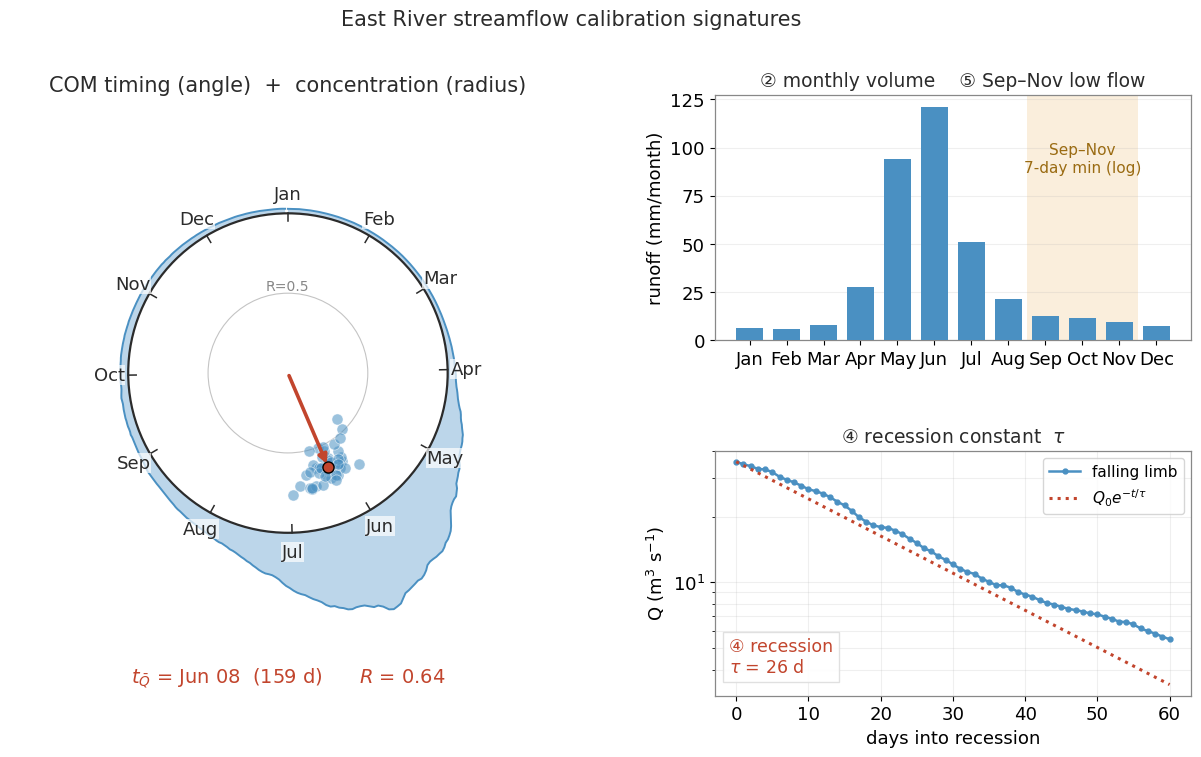

In [34]:
INK, BLUE, FILL, ACCENT, HL = "#2b2b2b", "#4a90c2", "#bcd6ea", "#c2452d", "#e8a33d"
plt.rcParams.update({"axes.edgecolor": "#888", "axes.linewidth": 0.9,
                     "font.size": 13, "axes.titlesize": 15, "axes.labelsize": 13})

def cal_xy(frac, r):
    """Calendar-year fraction (0 = Jan 1) -> x, y with Jan 1 at top, going clockwise."""
    a = np.pi / 2 - 2 * np.pi * np.asarray(frac)
    return r * np.cos(a), r * np.sin(a)

fig = plt.figure(figsize=(15.5, 7.8))
gs = fig.add_gridspec(2, 2, width_ratios=[1.25, 1.0], hspace=0.45, wspace=0.24)

# ============ LEFT: timing circle with the mean hydrograph wrapped around it ==
ax = fig.add_subplot(gs[:, 0]); ax.set_aspect("equal"); ax.axis("off")
RAD = 0.62                                                   # peak-flow reach beyond r=1

# the wrapped hydrograph = a filled band between the unit circle and r = 1 + RAD*Q/Qmax
frac = (np.arange(1, 366) - 1) / 365.0
ox, oy = cal_xy(frac, 1.0 + RAD * Qn)                        # outer edge (flow)
ix, iy = cal_xy(frac, 1.0)                                   # inner edge (circle)
ax.fill(np.r_[ox, ix[::-1]], np.r_[oy, iy[::-1]], color=FILL, lw=0, zorder=1)
ax.plot(ox, oy, color=BLUE, lw=1.4, zorder=2)

ax.add_patch(plt.Circle((0, 0), 0.5, fill=False, ec="#c4c4c4", lw=0.8, zorder=2))
ax.add_patch(plt.Circle((0, 0), 1.0, fill=False, ec=INK, lw=1.6, zorder=3))
ax.text(*cal_xy(0.0, 0.5), "R=0.5", fontsize=10, color="#888", ha="center", va="bottom")

for i, m in enumerate(range(1, 13)):                        # month ticks + labels (on the tick)
    f = (pd.Timestamp(f"2001-{m:02d}-01").dayofyear - 1) / 365.0
    x, y = cal_xy(f, 1.0)
    ax.plot([0.95 * x, x], [0.95 * y, y], color=INK, lw=1.1, zorder=5)
    ax.text(*cal_xy(f, 1.12), MLAB[i], fontsize=13, ha="center", va="center",
            color=INK, zorder=6, bbox=dict(fc="white", ec="none", alpha=0.7, pad=0.6))

for f, r in zip(ds["tQ_day"] / 365.0, ds["R"]):             # per-year cloud
    ax.plot(*cal_xy(f, r), "o", ms=8, color=BLUE, alpha=0.55, mec="white", mew=0.6, zorder=4)
mx, my = cal_xy(tQ_day / 365.0, Rbar)                       # mean resultant vector
ax.annotate("", xy=(mx, my), xytext=(0, 0), zorder=6,
            arrowprops=dict(arrowstyle="-|>", color=ACCENT, lw=2.6))
ax.plot(mx, my, "o", color=ACCENT, markeredgecolor='k', ms=8, zorder=7)

lim = 1.0 + RAD + 0.12
ax.set_xlim(-lim, lim); ax.set_ylim(-lim - 0.28, lim)
ax.set_title("COM timing (angle)  +  concentration (radius)", fontsize=15, color=INK, pad=2)
ax.text(0, -lim - 0.20, f"$t_{{\\bar Q}}$ = {tQ_date}  ({tQ_day:.0f} d)      $R$ = {Rbar:.2f}",
        ha="center", fontsize=14, color=ACCENT)

# ============ TOP-RIGHT: monthly volume + Sep-Nov low-flow window (② + ⑤) =====
axm = fig.add_subplot(gs[0, 1])
axm.axvspan(7.5, 10.5, color=HL, alpha=0.18, lw=0)          # Sep-Nov (idx 8,9,10)
axm.bar(np.arange(12), mvol.values, color=BLUE, width=0.72, zorder=3)
axm.set_xticks(np.arange(12)); axm.set_xticklabels(MLAB)
axm.set_ylabel("runoff (mm/month)")
axm.set_title("② monthly volume    ⑤ Sep–Nov low flow", fontsize=13.5, color=INK)
axm.annotate("Sep–Nov\n7-day min (log)", xy=(9, mvol.iloc[8:11].max() + 3),
             xytext=(9, mvol.max() * 0.72), color="#9a6b12", fontsize=11, ha="center",
             )
axm.grid(alpha=0.2, axis="y")

# ============ BOTTOM-RIGHT: recession constant tau (④), label at left ========
axr = fig.add_subplot(gs[1, 1])
pk = int(reg.idxmax()); seg = reg.loc[pk+10:pk+70]; t = np.arange(len(seg))
axr.semilogy(t, seg.values, color=BLUE, lw=1.8, marker="o", ms=3.5, label="falling limb")
axr.semilogy(t, seg.iloc[0] * np.exp(-t / tau), color=ACCENT, lw=2.2, ls=":", label=r"$Q_0e^{-t/\tau}$")
axr.text(0.03, 0.08, f"④ recession\n$\\tau$ = {tau:.0f} d", transform=axr.transAxes,
         ha="left", va="bottom", fontsize=12.5, color=ACCENT,
         bbox=dict(fc="white", ec="#ddd", alpha=0.9, pad=4))
axr.set_xlabel("days into recession"); axr.set_ylabel("Q (m$^3$ s$^{-1}$)")
axr.set_title("④ recession constant  $\\tau$", fontsize=13.5, color=INK)
axr.legend(fontsize=11, loc="upper right"); axr.grid(alpha=0.2, which="both")

fig.suptitle("East River streamflow calibration signatures",
             fontsize=15, color=INK, y=0.99)
plt.show()

## Evaluation example — reading a model against each tolerance

The definitions become a pass/fail check once each signature is given a **"good enough"
tolerance**. Below, the current best East calibration (as the *model*) is overlaid on the
observed record over its analysis window (WY1993–2002), and each tolerance is drawn as a
green band:

| signature | tolerance band |
|---|---|
| ① COM timing | observed COM date ± **7 days** |
| ② monthly volume | each observed month ± **max(10%, 4 mm)** (the significance filter) |
| ④ recession | observed $\tau$ ± **20%** |
| ⑤ Sep–Nov low flow | observed 7-day min **×/÷ 1.5** |

A model inside the band for a signature passes it; outside, it fails. (Concentration ③ is a
whole-hydrograph shape number without a natural "one-glance" band, so it is omitted here.)

In [3]:
import os
import xarray as xr

# The "model" is the current best East calibration; its analysis window is WY1993-2002.
SIM_NC = ("/scratch/dlhogan/ess-project-data/calibration/bestruns/"
          "East_River_current_best/run/out/best_timestep.nc")
EVAL0, EVAL1 = "1992-10-01", "2002-09-30"
assert os.path.exists(SIM_NC), f"model output not found:\n{SIM_NC}"

obs_e = obs[EVAL0:EVAL1].clip(lower=Q_FLOOR).dropna()
_d = xr.open_dataset(SIM_NC)
_t = pd.DatetimeIndex(_d["time"].values)
sim_e = (pd.Series(_d["averageRoutedRunoff"].isel(gru=0).values, index=_t) * AREA
         ).resample("D").mean()[EVAL0:EVAL1].clip(lower=Q_FLOOR).dropna()
_d.close()
_j = pd.concat({"o": obs_e, "s": sim_e}, axis=1).dropna()   # common days only
obs_e, sim_e = _j["o"], _j["s"]

# reuse directional_stats / recession_tau from above; add three small helpers
def regime(s):
    return s.groupby(s.index.dayofyear).mean().reindex(range(1, 366)).interpolate()

def monthly_mm(s):
    f = 86400 * 1000 / AREA / (len(s) / 365.25)
    return (s.groupby(s.index.month).sum() * f).reindex(range(1, 13))

def sepnov_min7_year(s):
    m7 = s[s.index.month.isin([9, 10, 11])].rolling(7, min_periods=4).mean()
    return m7.groupby(m7.index.year).min()

com_o = float(directional_stats(obs_e)["tQ_day"].mean())
com_s = float(directional_stats(sim_e)["tQ_day"].mean())
tau_o, tau_s = recession_tau(obs_e), recession_tau(sim_e)
reg_o, reg_s = regime(obs_e), regime(sim_e)
mvo,   mvs   = monthly_mm(obs_e), monthly_mm(sim_e)
lo_y,  ls_y  = sepnov_min7_year(obs_e), sepnov_min7_year(sim_e)
low_o, low_s = float(lo_y.mean()), float(ls_y.mean())

def dstr(day):
    return (pd.Timestamp("2001-01-01") + pd.Timedelta(days=day - 1)).strftime("%b %d")

print(f"COM obs {com_o:.0f} / model {com_s:.0f} d   tau obs {tau_o:.0f} / model {tau_s:.0f} d   "
      f"low obs {low_o:.2f} / model {low_s:.2f}")

COM obs 174 / model 173 d   tau obs 31 / model 40 d   low obs 2.11 / model 2.06


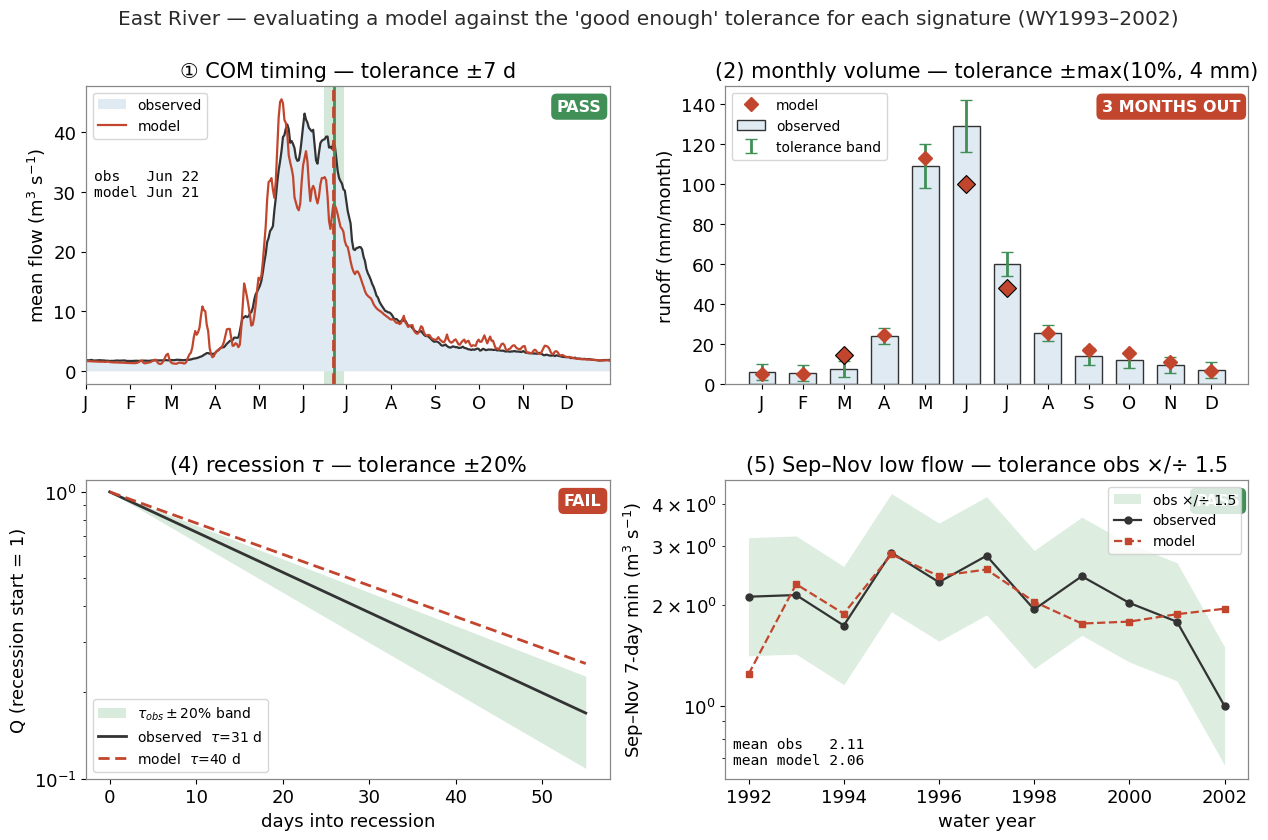

In [4]:
OBSC, SIMC, GOOD, BAD, GOODFILL = "#333333", "#c2452d", "#3f8f57", "#c2452d", "#cfe6d4"
JFMA = list("JFMAMJJASOND")

def badge(ax, passed, text):
    ax.text(0.985, 0.955, text, transform=ax.transAxes, ha="right", va="top",
            fontsize=11.5, weight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.35", fc=GOOD if passed else BAD, ec="none"))

fig, ax = plt.subplots(2, 2, figsize=(15, 9))
fig.subplots_adjust(hspace=0.32, wspace=0.22)
mticks = [pd.Timestamp(f"2001-{m:02d}-01").dayofyear for m in range(1, 13)]

# --- (1) COM timing: observed COM ±7 d --------------------------------------
a = ax[0, 0]; x = np.arange(1, 366)
a.fill_between(x, reg_o.values, color="#dfeaf3", lw=0, label="observed")
a.plot(x, reg_o.values, color=OBSC, lw=1.6)
a.plot(x, reg_s.values, color=SIMC, lw=1.6, label="model")
a.axvspan(com_o - 7, com_o + 7, color=GOODFILL, alpha=0.9, lw=0, zorder=0)
a.axvline(com_o, color=GOOD, lw=2); a.axvline(com_s, color=SIMC, ls=(0, (4, 2)), lw=2)
ok = abs(com_s - com_o) <= 7
a.set_xticks(mticks); a.set_xticklabels(JFMA); a.set_xlim(1, 365)
a.set_ylabel("mean flow (m$^3$ s$^{-1}$)"); a.set_title("① COM timing — tolerance ±7 d")
a.legend(loc="upper left", fontsize=10)
a.text(0.015, 0.72, f"obs   {dstr(com_o)}\nmodel {dstr(com_s)}", transform=a.transAxes,
       fontsize=10.5, va="top", family="monospace")
badge(a, ok, "PASS" if ok else "FAIL")

# --- (2) monthly volume: ±max(10%, 4 mm) ------------------------------------
b = ax[0, 1]; xp = np.arange(12); tol = np.maximum(0.10 * mvo.values, 4.0)
b.bar(xp, mvo.values, width=0.66, color="#dfeaf3", ec=OBSC, lw=1.0, label="observed", zorder=2)
b.errorbar(xp, mvo.values, yerr=tol, fmt="none", ecolor=GOOD, elinewidth=2, capsize=4,
           zorder=3, label="tolerance band")
b.plot(xp, mvs.values, "D", color=SIMC, ms=7, zorder=4, label="model")
bad = np.abs(mvs.values - mvo.values) > tol
for k in np.where(bad)[0]:
    b.plot(k, mvs.values[k], "D", color=BAD, ms=9, mec="k", mew=0.8, zorder=5)
b.set_xticks(xp); b.set_xticklabels(JFMA); b.set_ylabel("runoff (mm/month)")
b.set_title("(2) monthly volume — tolerance ±max(10%, 4 mm)")
b.legend(loc="upper left", fontsize=10)
badge(b, not bad.any(), "PASS" if not bad.any() else f"{bad.sum()} MONTHS OUT")

# --- (4) recession: fitted-tau decays vs the ±20% band ----------------------
c = ax[1, 0]; tt = np.arange(56)
c.fill_between(tt, np.exp(-tt / (tau_o * 0.8)), np.exp(-tt / (tau_o * 1.2)),
               color=GOODFILL, alpha=0.8, lw=0, label=r"$\tau_{obs}\pm20\%$ band")
c.semilogy(tt, np.exp(-tt / tau_o), color=OBSC, lw=2.0, label=rf"observed  $\tau$={tau_o:.0f} d")
c.semilogy(tt, np.exp(-tt / tau_s), color=SIMC, lw=2.0, ls=(0, (4, 2)),
           label=rf"model  $\tau$={tau_s:.0f} d")
ok_t = abs(tau_s - tau_o) / tau_o <= 0.20
c.set_ylim(0.1, 1.1); c.set_xlabel("days into recession")
c.set_ylabel("Q (recession start = 1)")
c.set_title(r"(4) recession $\tau$ — tolerance ±20%"); c.legend(loc="lower left", fontsize=10)
badge(c, ok_t, "PASS" if ok_t else "FAIL")

# --- (5) Sep-Nov low flow: per-year 7-day min, obs ×/÷ 1.5 ------------------
d = ax[1, 1]; yr = lo_y.index
d.fill_between(yr, lo_y.values / 1.5, lo_y.values * 1.5, color=GOODFILL, alpha=0.7, lw=0,
               label="obs ×/÷ 1.5")
d.plot(yr, lo_y.values, "o-", color=OBSC, lw=1.6, ms=5, label="observed")
d.plot(yr, ls_y.reindex(yr).values, "s--", color=SIMC, lw=1.6, ms=5, label="model")
d.set_yscale("log")
ok_l = abs(np.log10(low_s) - np.log10(low_o)) <= np.log10(1.5)
d.set_xlabel("water year"); d.set_ylabel("Sep–Nov 7-day min (m$^3$ s$^{-1}$)")
d.set_title(r"(5) Sep–Nov low flow — tolerance obs ×/÷ 1.5"); d.legend(loc="upper right", fontsize=10)
d.text(0.015, 0.14, f"mean obs   {low_o:.2f}\nmean model {low_s:.2f}", transform=d.transAxes,
       fontsize=10.5, va="top", family="monospace")
badge(d, ok_l, "PASS" if ok_l else "FAIL")

fig.suptitle("East River — evaluating a model against the 'good enough' tolerance for each "
             "signature (WY1993–2002)", fontsize=14.5, y=0.965, color="#2b2b2b")
plt.show()

## Scalar flow evaluation — 1:1 with observation uncertainty

Two evaluation signatures held out of calibration: the **AMJJ freshet volume** (Apr–Jul
runoff) and the **annual runoff volume**. Both are volumes (mm), so a point's distance
from the 1:1 line *is* its volume bias — easier to compare than a fraction.

The green band is a **95% observation-uncertainty envelope**: observed ± 1.96·σ, with
σ ≈ 5% gauging uncertainty on seasonal/annual volumes (adjust `SIGMA_OBS` below).
**Ringed years fall outside it** — the model–obs gap there exceeds what gauge error can
explain. Each panel also reports the mean % bias with its 95% confidence interval.

(This is the deliberate alternative to a *prediction interval* from the 10-yr scatter,
which at ±40% would be too wide to flag any year — with n = 10 the discriminating band
has to come from observation uncertainty, not model spread.)

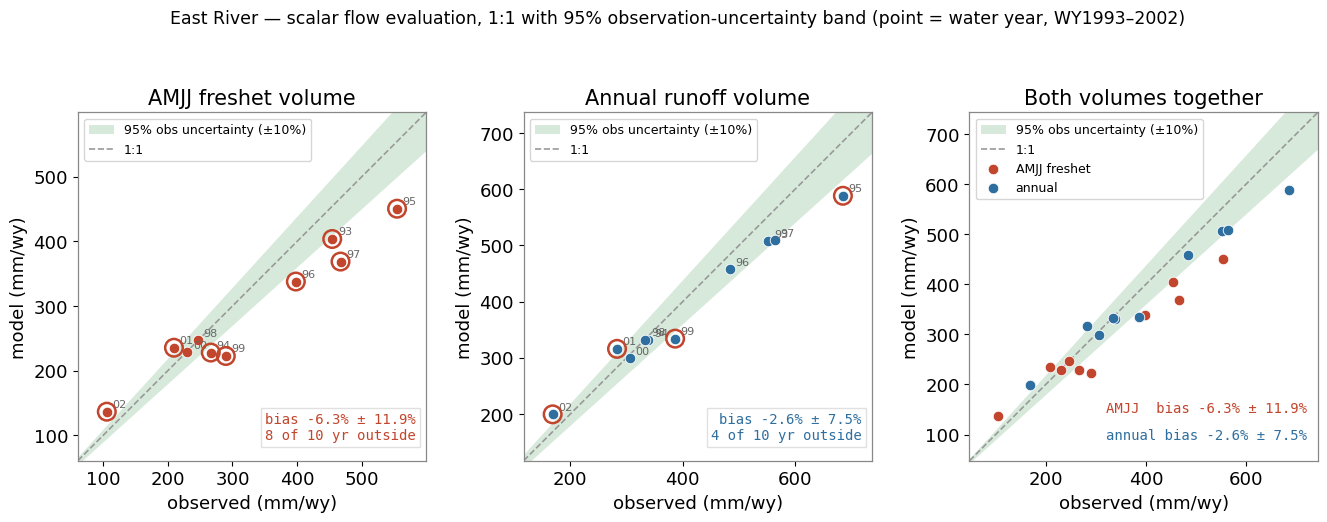

In [5]:
from scipy import stats

# both signatures as VOLUMES (mm) so distance from the 1:1 line reads as volume bias
def _wy(idx): return idx.year + (idx.month >= 10)
_mmf = 86400 * 1000 / AREA
def volume(s, months=None):
    v = s * _mmf
    if months is not None:
        v = v[v.index.month.isin(months)]
    return v.groupby(_wy(v.index)).sum()

amjj_o, amjj_s = volume(obs_e, (4, 5, 6, 7)), volume(sim_e, (4, 5, 6, 7))
ann_o,  ann_s  = volume(obs_e), volume(sim_e)

# 95% observation-uncertainty envelope: obs ± 1.96·σ_gauge (σ ≈ 5% for USGS
# annual/seasonal volumes). A year outside = model–obs gap exceeds gauge error.
SIGMA_OBS, Z95 = 0.05, 1.96
OBS_BAND = Z95 * SIGMA_OBS

def err(o, s):
    e = (s.reindex(o.index).values - o.values) / o.values          # fractional error
    tv = stats.t.ppf(0.975, len(e) - 1)
    return e, e.mean(), tv * e.std(ddof=1) / np.sqrt(len(e))        # errors, mean bias, 95% CI

C_AMJJ, C_ANN, RING, FILL2 = "#c2452d", "#2f6f9f", "#c2452d", "#cfe6d4"

def one_to_one(a, o, s, color, title, band=True):
    e, mu, ci = err(o, s)
    lo = min(o.min(), s.min()); hi = max(o.max(), s.max()); pad = 0.10 * (hi - lo)
    lo, hi = lo - pad, hi + pad; xx = np.array([lo, hi])
    if band:
        a.fill_between(xx, xx * (1 - OBS_BAND), xx * (1 + OBS_BAND), color=FILL2, alpha=0.85,
                       lw=0, zorder=0, label=f"95% obs uncertainty (±{OBS_BAND:.0%})")
    a.plot(xx, xx, color="#999", lw=1.2, ls="--", label="1:1", zorder=1)
    out = np.abs(e) > OBS_BAND
    a.scatter(o.values, s.reindex(o.index).values, s=58, color=color, ec="white", lw=0.6, zorder=3)
    for k, y in enumerate(o.index):
        if out[k]:
            a.scatter(o[y], s[y], s=160, facecolors="none", edgecolors=RING, lw=1.8, zorder=4)
        a.annotate(str(y)[-2:], (o[y], s[y]), fontsize=8, color="#666",
                   xytext=(4, 3), textcoords="offset points")
    a.set_xlim(lo, hi); a.set_ylim(lo, hi); a.set_aspect("equal")
    a.set_xlabel("observed (mm/wy)"); a.set_ylabel("model (mm/wy)"); a.set_title(title)
    a.text(0.97, 0.06, f"bias {100*mu:+.1f}% ± {100*ci:.1f}%\n{out.sum()} of {len(out)} yr outside",
           transform=a.transAxes, ha="right", fontsize=10, family="monospace", color=color,
           bbox=dict(fc="white", ec="#ddd", alpha=0.9, pad=3))
    a.legend(loc="upper left", fontsize=9)

fig, ax = plt.subplots(1, 3, figsize=(16, 5.6)); fig.subplots_adjust(wspace=0.28)
one_to_one(ax[0], amjj_o, amjj_s, C_AMJJ, "AMJJ freshet volume")
one_to_one(ax[1], ann_o, ann_s, C_ANN, "Annual runoff volume")

# combined: the ±obs band is relative, so one envelope covers both point sets
lo = min(amjj_o.min(), amjj_s.min(), ann_o.min(), ann_s.min())
hi = max(amjj_o.max(), amjj_s.max(), ann_o.max(), ann_s.max()); pad = 0.10 * (hi - lo)
lo, hi = lo - pad, hi + pad; xx = np.array([lo, hi])
ax[2].fill_between(xx, xx * (1 - OBS_BAND), xx * (1 + OBS_BAND), color=FILL2, alpha=0.85, lw=0,
                   zorder=0, label=f"95% obs uncertainty (±{OBS_BAND:.0%})")
ax[2].plot(xx, xx, color="#999", lw=1.2, ls="--", label="1:1", zorder=1)
ax[2].scatter(amjj_o.values, amjj_s.reindex(amjj_o.index).values, s=58, color=C_AMJJ,
              ec="white", lw=0.6, label="AMJJ freshet", zorder=3)
ax[2].scatter(ann_o.values, ann_s.reindex(ann_o.index).values, s=58, color=C_ANN,
              ec="white", lw=0.6, label="annual", zorder=3)
_, mua, cia = err(amjj_o, amjj_s); _, mun, cin = err(ann_o, ann_s)
ax[2].text(0.97, 0.14, f"AMJJ  bias {100*mua:+.1f}% ± {100*cia:.1f}%", transform=ax[2].transAxes,
           ha="right", fontsize=10, family="monospace", color=C_AMJJ)
ax[2].text(0.97, 0.06, f"annual bias {100*mun:+.1f}% ± {100*cin:.1f}%", transform=ax[2].transAxes,
           ha="right", fontsize=10, family="monospace", color=C_ANN)
ax[2].set_xlim(lo, hi); ax[2].set_ylim(lo, hi); ax[2].set_aspect("equal")
ax[2].set_xlabel("observed (mm/wy)"); ax[2].set_ylabel("model (mm/wy)")
ax[2].set_title("Both volumes together"); ax[2].legend(loc="upper left", fontsize=9)

fig.suptitle("East River — scalar flow evaluation, 1:1 with 95% observation-uncertainty band "
             "(point = water year, WY1993–2002)", fontsize=12.5, y=0.99)
plt.show()

## Can the model recreate the observations? — regression against 1:1

Fit an OLS line to the paired volumes (model on observed, one point per water year) and
ask whether it is consistent with the 1:1 line:

- **slope** — a slope < 1 means the model compresses the range (under-predicts wet years,
  over-predicts dry). The ± is the 95% CI; "excl. 1" means the compression is significant.
- **confidence band** — uncertainty in the fitted line itself. Where the 1:1 line leaves
  it, the model is inconsistent with unbiased agreement.
- **F-test** — a single test of H₀: *the line is 1:1* (intercept = 0 **and** slope = 1). It
  compares the free OLS fit against the forced 1:1 line; a small *p* means the free fit
  explains significantly more than 1:1, i.e. the data depart from 1:1 by more than noise.
  This is the headline significance statement — and it beats a paired bias test, which
  **cancels here**: over-prediction of dry years offsets under-prediction of wet years, so
  a mean-difference test sees little, while the F-test sees the tilt.

R² is ranking skill (does the model order wet/dry years right); the slope is amplitude
fidelity. Because R² is high, slope < 1 is genuine variance compression, not a
regression-to-the-mean artefact.

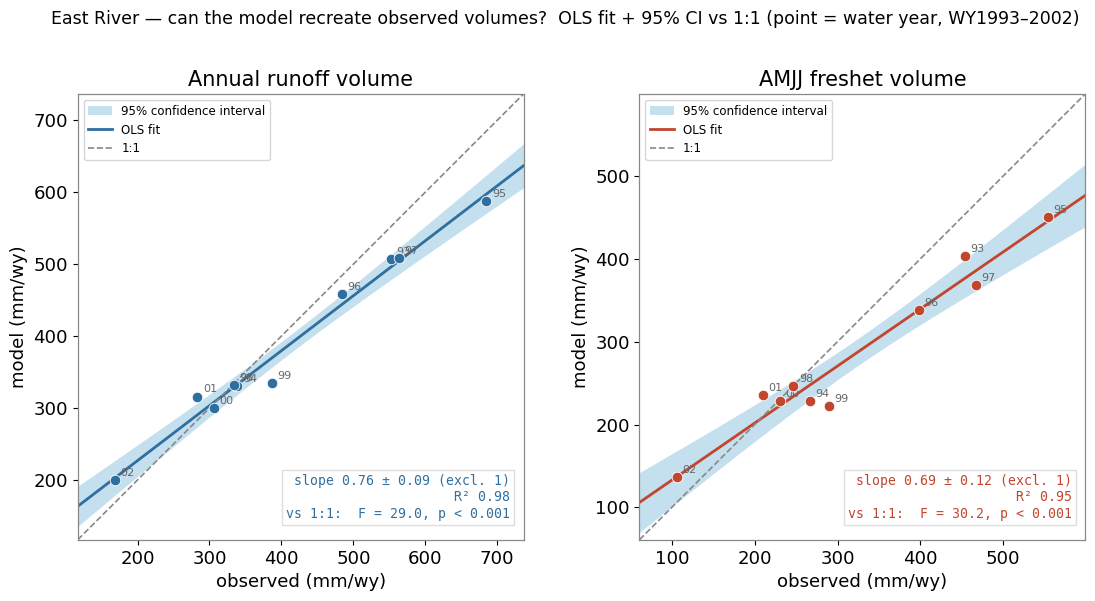

Annual  volume — line vs 1:1:  F(2,8) = 29.01,  p = 0.0002157
AMJJ freshet   — line vs 1:1:  F(2,8) = 30.18,  p = 0.0001876


In [6]:
def regress_fit(o, s):
    """OLS of model (y) on observed (x), plus the F-test that the line IS 1:1."""
    x, y = o.values.astype(float), s.reindex(o.index).values.astype(float)
    n = len(x); lr = stats.linregress(x, y)                     # y = intercept + slope*x
    sse = np.sum((y - (lr.intercept + lr.slope * x)) ** 2)      # free OLS fit
    sse_11 = np.sum((y - x) ** 2)                               # restricted: forced y = x
    F = ((sse_11 - sse) / 2) / (sse / (n - 2)); pF = stats.f.sf(F, 2, n - 2)
    sd = np.sqrt(sse / (n - 2)); xbar = x.mean(); Sxx = np.sum((x - xbar) ** 2)
    tv = stats.t.ppf(0.975, n - 2)
    return x, y, lr, sd, xbar, Sxx, tv, n, F, pF

def reg_panel(a, o, s, color, title):
    x, y, lr, sd, xbar, Sxx, tv, n, F, pF = regress_fit(o, s)
    lo = min(x.min(), y.min()); hi = max(x.max(), y.max()); pad = 0.10 * (hi - lo)
    lo, hi = lo - pad, hi + pad; g = np.linspace(lo, hi, 100); yg = lr.intercept + lr.slope * g
    se_m = sd * np.sqrt(1 / n + (g - xbar) ** 2 / Sxx)          # confidence band (fitted line)
    a.fill_between(g, yg - tv * se_m, yg + tv * se_m, color="#9ecae1", alpha=0.6, lw=0, zorder=1,
                   label="95% confidence interval")
    a.plot(g, yg, color=color, lw=2, zorder=2, label="OLS fit")
    a.plot([lo, hi], [lo, hi], color="#888", lw=1.2, ls="--", zorder=2, label="1:1")
    a.scatter(x, y, s=58, color=color, ec="white", lw=0.6, zorder=4)
    for k, yr in enumerate(o.index):
        a.annotate(str(yr)[-2:], (x[k], y[k]), fontsize=8, color="#666",
                   xytext=(4, 3), textcoords="offset points")
    a.set_xlim(lo, hi); a.set_ylim(lo, hi); a.set_aspect("equal")
    a.set_xlabel("observed (mm/wy)"); a.set_ylabel("model (mm/wy)"); a.set_title(title)
    bci = tv * lr.stderr; one_in = lr.slope - bci <= 1 <= lr.slope + bci
    pstr = "p < 0.001" if pF < 0.001 else f"p = {pF:.3f}"
    a.text(0.97, 0.05,
           f"slope {lr.slope:.2f} ± {bci:.2f} ({'incl. 1' if one_in else 'excl. 1'})\n"
           f"R² {lr.rvalue**2:.2f}\nvs 1:1:  F = {F:.1f}, {pstr}",
           transform=a.transAxes, ha="right", fontsize=9.5, family="monospace", color=color,
           bbox=dict(fc="white", ec="#ddd", alpha=0.95, pad=3))
    a.legend(loc="upper left", fontsize=8.5)
    return F, pF, n

fig, ax = plt.subplots(1, 2, figsize=(13, 6.2)); fig.subplots_adjust(wspace=0.26)
Fa, pa, na = reg_panel(ax[0], ann_o, ann_s, C_ANN, "Annual runoff volume")
Ff, pf, nf = reg_panel(ax[1], amjj_o, amjj_s, C_AMJJ, "AMJJ freshet volume")
fig.suptitle("East River — can the model recreate observed volumes?  OLS fit + 95% CI vs 1:1 "
             "(point = water year, WY1993–2002)", fontsize=12.5, y=0.99)
plt.show()

# F-test that the fitted line equals the 1:1 line  (H0: intercept = 0 and slope = 1)
print(f"Annual  volume — line vs 1:1:  F(2,{na-2}) = {Fa:.2f},  p = {pa:.4g}")
print(f"AMJJ freshet   — line vs 1:1:  F(2,{nf-2}) = {Ff:.2f},  p = {pf:.4g}")

In [7]:
# Evaluation metrics
# 1. streamflow recession (low flow)
# 2. AMJJ runoff fraction/bias (spring freshet)
# 3. Annual flow volume (total flow bias)
# 5. ASO SWE (spatial SWE pattern)
# 6. Spatial ET (spatial ET pattern)